# 1.0 Importação das Bibliotecas Usadas e do Dataset

In [20]:
import pandas as pd
import numpy as np
from sklearn import model_selection
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("dataset_tratado.csv")

In [3]:
df

,Unnamed: 0,Age,CDR,SES,nWBV,Visit,MMSE,ASF,eTIV,Group,MR Delay
0,0,87.0,0.0,2.0,0.696106,1.0,27.0,0.883440,1986.550000,0.0,0.0
1,1,88.0,0.0,2.0,0.681062,2.0,30.0,0.875539,2004.479526,0.0,457.0
2,2,75.0,0.5,1.8,0.736336,1.0,23.0,1.045710,1678.290000,1.0,0.0
3,3,76.0,0.5,1.6,0.713402,2.0,28.0,1.010000,1737.620000,1.0,560.0
4,4,80.0,0.5,2.6,0.701236,3.0,22.0,1.033623,1697.911134,1.0,1895.0
...,...,...,...,...,...,...,...,...,...,...,...
368,368,82.0,0.5,1.0,0.693926,2.0,28.0,1.036690,1692.880000,1.0,842.0
369,369,86.0,0.5,1.0,0.675457,3.0,26.0,1.039686,1688.009649,1.0,2297.0
370,370,61.0,0.0,2.0,0.801006,1.0,30.0,1.330540,1319.020000,0.0,0.0
371,371,63.0,0.0,2.0,0.795981,2.0,30.0,1.322890,1326.650000,0.0,763.0


# 2.0 Pre-processamento dos Dados

## 2.1 Criando X e y

In [4]:
X = np.array(df.drop(['Group'], axis=1))
y = np.array(df['Group'])

## 2.2 Separando em Treino e Teste

In [5]:
RANDOM_STATE = 2

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, random_state=RANDOM_STATE, test_size=0.2)

# 3.0 Modelagem dos Dados

In [6]:
def Modelagem(X_train, y_train, X_test, Modelo):
    
    pca_pipeline = Pipeline([
        ('scaler', StandardScaler()),        
        ('pca', PCA(n_components=0.95)),      
        ('modelo', Modelo())   
    ])
    
    pca_pipeline.fit(X_train, y_train)

    
    previsoes = pca_pipeline.predict(X_test)
    
    return pca_pipeline, previsoes  

# Adaboost

## Função objetivo do AdaBoost

Formalmente, o AdaBoost tenta minimizar a seguinte função objetivo:

$$
L = \sum_{i=1}^{n} \exp(-y_i F(x_i))
$$

onde:

- $y_i \in \{-1, +1\}$ é o rótulo verdadeiro  
- $F(x_i)$ é o modelo final (combinação dos *weak learners*)  

O modelo final é dado por:

$$
F(x) = \sum_{t=1}^{T} \alpha_t h_t(x)
$$

onde:

- $h_t(x)$ são os classificadores fracos  
- $\alpha_t$ são os pesos de cada classificador

In [8]:
pipeline, previsoes = Modelagem(X_train, y_train, X_test, AdaBoostClassifier)

In [9]:
print(classification_report(y_test, previsoes, target_names=['0', '1']))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97        46
           1       0.96      0.93      0.95        29

    accuracy                           0.96        75
   macro avg       0.96      0.95      0.96        75
weighted avg       0.96      0.96      0.96        75



## Mudando os Métodos de Otimização

### Extraindo o Adaboost Treinado no Pipeline

In [10]:
ada = pipeline.named_steps['modelo']

### Aplicando scaler e PCA no treino

In [11]:
pca_saida = pipeline[:-1].transform(X_train)

### Pegando o número de estimadores base treinados pelo AdaBoost

In [12]:
n_est = len(ada.estimators_)

### Montando Matriz de Predições

Cada estimador do AdaBoost vota numa classe (-1 ou 1). O minimize precisa dessas predições organizadas em forma de matriz para calcular a loss e o gradiente. Aí quando você faz H @ alphas, está calculando o voto ponderado de todos os estimadores para cada amostra

In [13]:
H = np.zeros((X_train.shape[0], n_est))

for t, estimador in enumerate(ada.estimators_):
    H[:, t] = estimador.predict(pca_saida)

### Convertendo Labels 0/1 Para -1/1 

In [14]:
y_train_signed = np.where(y_train == 0, -1, 1)

### Funções Usadas No Minimize

In [15]:
def loss_exp(alphas, H, y):
    
    margem = np.clip(H @ alphas, -500, 500)
    
    return np.mean(np.exp(-y * margem))


def grad_loss(alphas, H, y):
    
    margem = np.clip(H @ alphas, -500, 500)
    
    pesos = -y * np.exp(-y * margem)  
    
    return (H.T @ pesos) / len(y)    

### Criando H_test Para Comparação Entre Alfas Obtidos

In [16]:
pca_saida_test = pipeline[:-1].transform(X_test)

H_test = np.zeros((X_test.shape[0], n_est))

for t, estimador in enumerate(ada.estimators_):
    H_test[:, t] = estimador.predict(pca_saida_test)

In [18]:
methods = {
    'CG':        None,   # gradiente conjugado
    'BFGS':      None,   # quase-Newton denso
    'Newton-CG': None,   # Newton com gradiente conjugado interno
    'L-BFGS-B':  None    # quase-Newton com memória limitada
}

historicos = {}


for met, bounds in methods.items():
    historico = []
    
    def callback(alphas):
        historico.append(alphas.copy())
        
    result = minimize(
        loss_exp,
        x0=ada.estimator_weights_,  # chute inicial
        jac=grad_loss,              # gradiente analítico 
        args=(H, y_train_signed),
        method=met,
        bounds=bounds,
        callback=callback
    )
    
    historicos[met] = np.array(historico)
    alphas_otimizados = result.x

    # combinação linear dos estimadores com alfas otimizados
    previsoes_otimizadas = np.sign(H_test @ alphas_otimizados)

    # converte de volta para 0/1 (de -1/1)
    previsoes_otimizadas = np.where(previsoes_otimizadas == -1, 0, 1).astype(int)

    print(f"Método:     {met}")
    print(f"Convergiu:  {result.success}")
    print(f"Loss final: {result.fun:.6f}")
    print(f"Iterações:  {result.nit}")
    print(f"Acurácia:   {accuracy_score(y_test, previsoes_otimizadas):.4f}")
    print("----------------")

Método:     CG
Convergiu:  True
Loss final: 0.218339
Iterações:  450
Acurácia:   0.8267
----------------
Método:     BFGS
Convergiu:  True
Loss final: 0.218331
Iterações:  290
Acurácia:   0.8267
----------------
Método:     Newton-CG
Convergiu:  False
Loss final: 0.218341
Iterações:  23
Acurácia:   0.8267
----------------
Método:     L-BFGS-B
Convergiu:  True
Loss final: 0.218331
Iterações:  189
Acurácia:   0.8267
----------------


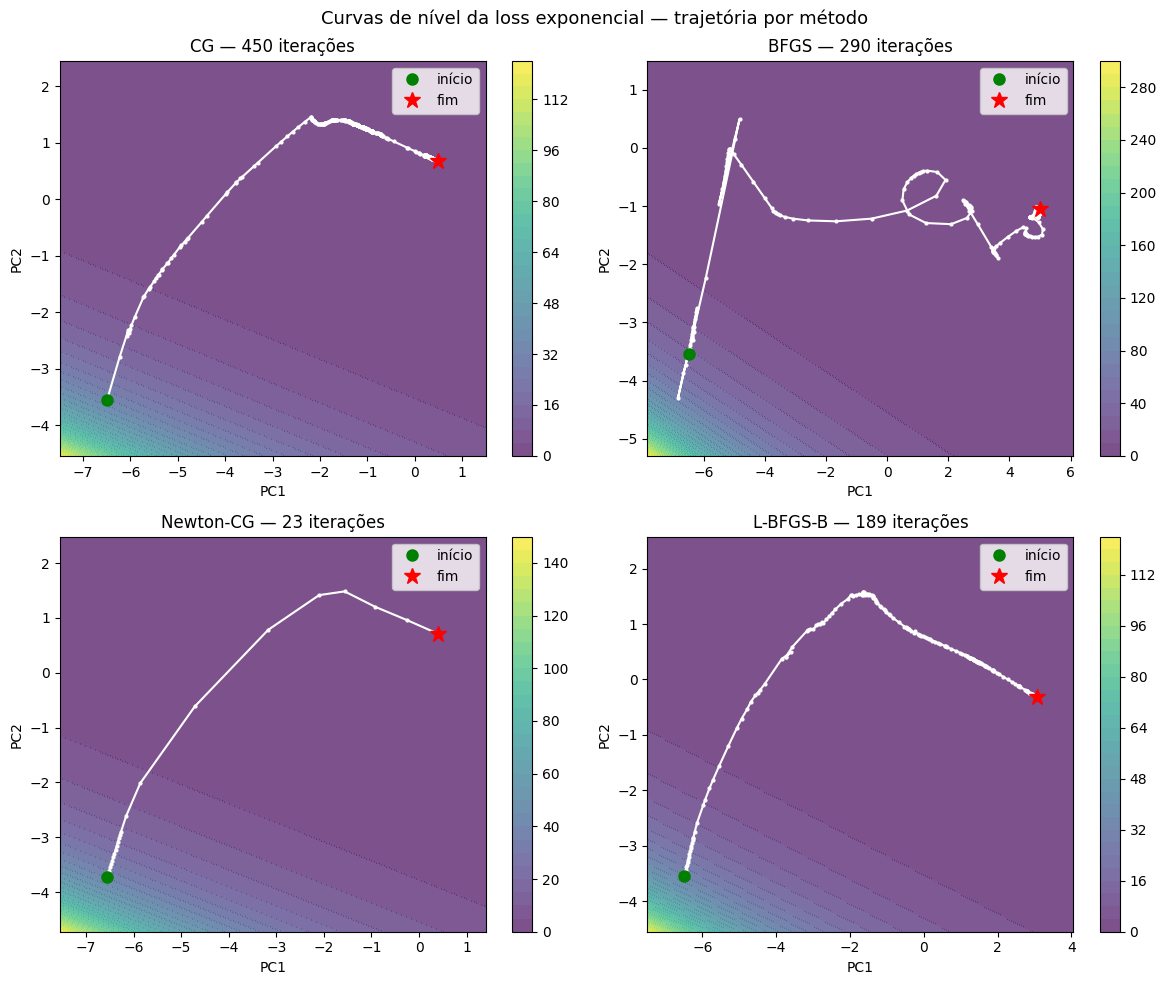

In [19]:
# junta todos os históricos para PCA
todos = np.vstack(list(historicos.values()))
pca2d = PCA(n_components=2).fit(todos)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (met, hist) in enumerate(historicos.items()):
    ax = axes[i]
    
    # projeta trajetória em 2D
    traj = pca2d.transform(hist)
    
    # grade para curvas de nível
    x_min, x_max = traj[:, 0].min() - 1, traj[:, 0].max() + 1
    y_min, y_max = traj[:, 1].min() - 1, traj[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # reconstrói alfas a partir da grade 2D
    grid_2d = np.c_[xx.ravel(), yy.ravel()]
    grid_nd = pca2d.inverse_transform(grid_2d)
    zz = np.array([loss_exp(a, H, y_train_signed) for a in grid_nd])
    zz = zz.reshape(xx.shape)
    
    # curvas de nível + trajetória
    cp = ax.contourf(xx, yy, zz, levels=30, cmap='viridis', alpha=0.7)
    ax.contour(xx, yy, zz, levels=30, colors='white', linewidths=0.3, alpha=0.5)
    ax.plot(traj[:, 0], traj[:, 1], 'w.-', markersize=4, linewidth=1.5)
    ax.plot(traj[0, 0],  traj[0, 1],  'go', markersize=8, label='início')
    ax.plot(traj[-1, 0], traj[-1, 1], 'r*', markersize=12, label='fim')
    
    fig.colorbar(cp, ax=ax)
    ax.set_title(f'{met} — {len(hist)} iterações')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend()

plt.suptitle('Curvas de nível da loss exponencial — trajetória por método', fontsize=13)
plt.tight_layout()
plt.show()